In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load drug names
drug_names = pd.read_csv(
    "/content/drug_names.tsv",
    sep="\t",
    header=None,
    names=["STITCH_ID", "Drug_Name"]
)

drug_names.columns = drug_names.columns.str.lower()

drug_names.head()

,stitch_id,drug_name
0,CID100000085,carnitine
1,CID100000119,gamma-aminobutyric
2,CID100000137,5-aminolevulinic
3,CID100000143,leucovorin
4,CID100000146,5-methyltetrahydrofolate


In [3]:
# Load indications data
indications = pd.read_csv(
    "/content/meddra_all_indications.tsv",
    sep="\t",
    header=None,
    names=[
        "STITCH_ID",
        "UMLS_ID",
        "Detection_Method",
        "Indication_Name",
        "MedDRA_Type",
        "UMLS_ID2",
        "MedDRA_Indication_Name"
    ]
)

indications.columns = indications.columns.str.lower()

indications.head()

,stitch_id,umls_id,detection_method,indication_name,meddra_type,umls_id2,meddra_indication_name
0,CID100000085,C0015544,text_mention,Failure to Thrive,LLT,C0015544,Failure to thrive
1,CID100000085,C0015544,text_mention,Failure to Thrive,PT,C0015544,Failure to thrive
2,CID100000085,C0020615,text_mention,Hypoglycemia,LLT,C0020615,Hypoglycaemia
3,CID100000085,C0020615,text_mention,Hypoglycemia,PT,C0020615,Hypoglycaemia
4,CID100000085,C0022661,NLP_indication,"Kidney Failure, Chronic",LLT,C0022661,Renal failure chronic


In [4]:
# Load side effects data
side_effects = pd.read_csv(
    "/content/meddra_all_se.tsv",
    sep="\t",
    header=None,
    names=[
        "STITCH_ID_flat",
        "STITCH_ID_stereo",
        "UMLS_ID",
        "Concept_Type",
        "MedDRA_UMLS_ID",
        "Side_Effect_Name"
    ]
)

side_effects.columns = side_effects.columns.str.lower()

side_effects.head()

,stitch_id_flat,stitch_id_stereo,umls_id,concept_type,meddra_umls_id,side_effect_name
0,CID100000085,CID000010917,C0000729,LLT,C0000729,Abdominal cramps
1,CID100000085,CID000010917,C0000729,PT,C0000737,Abdominal pain
2,CID100000085,CID000010917,C0000737,LLT,C0000737,Abdominal pain
3,CID100000085,CID000010917,C0000737,PT,C0687713,Gastrointestinal pain
4,CID100000085,CID000010917,C0000737,PT,C0000737,Abdominal pain


In [5]:
#Merge indications with drug names
merged_indications = pd.merge(
    indications,
    drug_names,
    on="stitch_id",
    how="left"
)

merged_indications.drop_duplicates(inplace=True)
merged_indications.dropna(inplace=True)

print("Merged indications shape:", merged_indications.shape)
merged_indications.head()

Merged indications shape: (30476, 8)


,stitch_id,umls_id,detection_method,indication_name,meddra_type,umls_id2,meddra_indication_name,drug_name
0,CID100000085,C0015544,text_mention,Failure to Thrive,LLT,C0015544,Failure to thrive,carnitine
1,CID100000085,C0015544,text_mention,Failure to Thrive,PT,C0015544,Failure to thrive,carnitine
2,CID100000085,C0020615,text_mention,Hypoglycemia,LLT,C0020615,Hypoglycaemia,carnitine
3,CID100000085,C0020615,text_mention,Hypoglycemia,PT,C0020615,Hypoglycaemia,carnitine
4,CID100000085,C0022661,NLP_indication,"Kidney Failure, Chronic",LLT,C0022661,Renal failure chronic,carnitine


In [6]:
#Merge indications with drug names
merged_se = pd.merge(
    side_effects,
    drug_names,
    left_on="stitch_id_flat",
    right_on="stitch_id",
    how="left"
)

merged_se.drop_duplicates(inplace=True)
merged_se.dropna(inplace=True)

# Drop duplicate STITCH column from drug_names
merged_se.drop(columns=["stitch_id"], inplace=True)

print("Merged side effects shape:", merged_se.shape)
merged_se.head()

Merged side effects shape: (308948, 7)


,stitch_id_flat,stitch_id_stereo,umls_id,concept_type,meddra_umls_id,side_effect_name,drug_name
0,CID100000085,CID000010917,C0000729,LLT,C0000729,Abdominal cramps,carnitine
1,CID100000085,CID000010917,C0000729,PT,C0000737,Abdominal pain,carnitine
2,CID100000085,CID000010917,C0000737,LLT,C0000737,Abdominal pain,carnitine
3,CID100000085,CID000010917,C0000737,PT,C0687713,Gastrointestinal pain,carnitine
4,CID100000085,CID000010917,C0000737,PT,C0000737,Abdominal pain,carnitine


In [7]:
#Merge side effects and indications together
df = pd.merge(
    merged_se,
    merged_indications,
    left_on="stitch_id_flat",
    right_on="stitch_id",
    how="inner",
    suffixes=("_se", "_ind")
)

df.drop(columns=["stitch_id"], inplace=True)

print("Merged full dataset shape:", df.shape)
df.head()

Merged full dataset shape: (10469014, 14)


,stitch_id_flat,stitch_id_stereo,umls_id_se,concept_type,meddra_umls_id,side_effect_name,drug_name_se,umls_id_ind,detection_method,indication_name,meddra_type,umls_id2,meddra_indication_name,drug_name_ind
0,CID100000085,CID000010917,C0000729,LLT,C0000729,Abdominal cramps,carnitine,C0015544,text_mention,Failure to Thrive,LLT,C0015544,Failure to thrive,carnitine
1,CID100000085,CID000010917,C0000729,LLT,C0000729,Abdominal cramps,carnitine,C0015544,text_mention,Failure to Thrive,PT,C0015544,Failure to thrive,carnitine
2,CID100000085,CID000010917,C0000729,LLT,C0000729,Abdominal cramps,carnitine,C0020615,text_mention,Hypoglycemia,LLT,C0020615,Hypoglycaemia,carnitine
3,CID100000085,CID000010917,C0000729,LLT,C0000729,Abdominal cramps,carnitine,C0020615,text_mention,Hypoglycemia,PT,C0020615,Hypoglycaemia,carnitine
4,CID100000085,CID000010917,C0000729,LLT,C0000729,Abdominal cramps,carnitine,C0022661,NLP_indication,"Kidney Failure, Chronic",LLT,C0022661,Renal failure chronic,carnitine


In [8]:
# Drop unnecessary columns
df.drop(
    columns=[
        "stitch_id_stereo",
        "meddra_umls_id",
        "drug_name_se",
        "umls_id_ind",
        "detection_method",
        "indication_name"
    ],
    inplace=True
)

# Rename columns to match final expected output
df.rename(
    columns={
        "drug_name_ind": "drug_name",
        "meddra_indication_name": "indication_name"
    },
    inplace=True
)

# Final cleanup
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

# reorder columns for consistency
df = df[
    [
        "stitch_id_flat",
        "umls_id_se",
        "concept_type",
        "side_effect_name",
        "meddra_type",
        "umls_id2",
        "indication_name",
        "drug_name"
    ]
]

print("Final merged dataset shape:", df.shape)
df.head()

Final merged dataset shape: (9312040, 8)


,stitch_id_flat,umls_id_se,concept_type,side_effect_name,meddra_type,umls_id2,indication_name,drug_name
0,CID100000085,C0000729,LLT,Abdominal cramps,LLT,C0015544,Failure to thrive,carnitine
1,CID100000085,C0000729,LLT,Abdominal cramps,PT,C0015544,Failure to thrive,carnitine
2,CID100000085,C0000729,LLT,Abdominal cramps,LLT,C0020615,Hypoglycaemia,carnitine
3,CID100000085,C0000729,LLT,Abdominal cramps,PT,C0020615,Hypoglycaemia,carnitine
4,CID100000085,C0000729,LLT,Abdominal cramps,LLT,C0022661,Renal failure chronic,carnitine


In [10]:
df.to_csv("merged_data.csv", index=False)

print("Saved merged.csv")
print("Final shape:", df.shape)
print("Final columns:")
print(df.columns.tolist())

Saved merged.csv
Final shape: (9312040, 8)
Final columns:
['stitch_id_flat', 'umls_id_se', 'concept_type', 'side_effect_name', 'meddra_type', 'umls_id2', 'indication_name', 'drug_name']


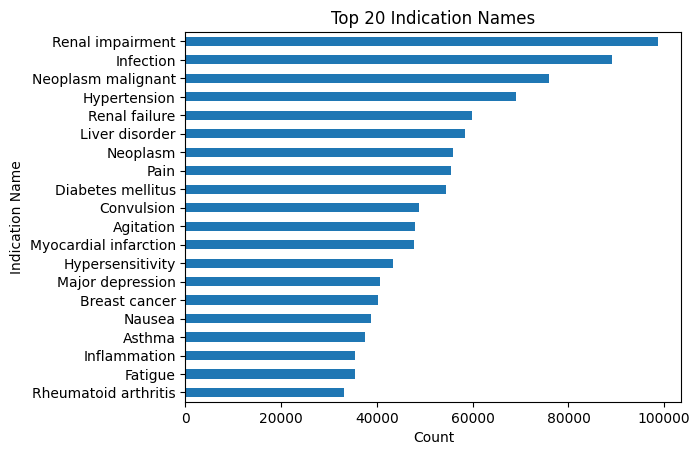

In [11]:
df["indication_name"].value_counts().head(20).plot(
    kind="barh",
    xlabel="Count",
    ylabel="Indication Name",
    title="Top 20 Indication Names"
)

plt.gca().invert_yaxis()
plt.show()

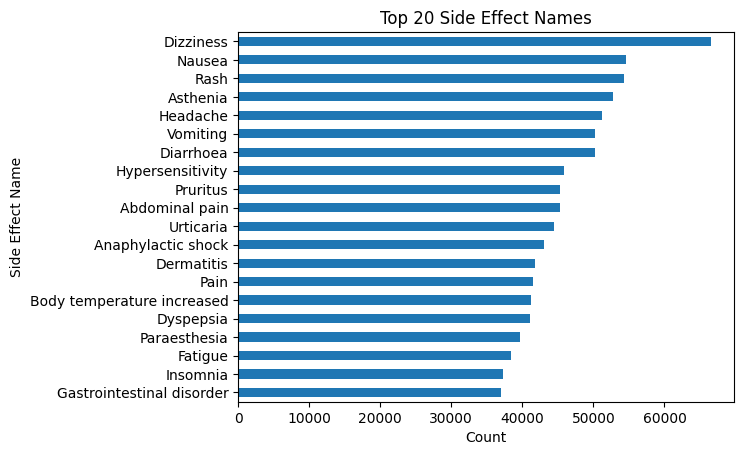

In [12]:
df["side_effect_name"].value_counts().head(20).plot(
    kind="barh",
    xlabel="Count",
    ylabel="Side Effect Name",
    title="Top 20 Side Effect Names"
)

plt.gca().invert_yaxis()
plt.show()